In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix

import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, Ridge 
from sklearn.metrics import log_loss  # --- Logistic regression with different regularisation strengths --- 
from sklearn.impute import SimpleImputer, KNNImputer

In [6]:
df_raw = pd.read_csv("./data/cibil_score/cibil_score.csv")

In [ ]:
# df_processed = pd.read_csv("./data/cibil_score/cibil_")

● Chart types that matter for ML: distribution plots, pair plots, heatmaps, learning curves, residual plots

● Common visualisation mistakes: misleading axes, overcrowded plots, wrong chart types

● Visualising model outputs: predicted probability distributions, actual vs predicted scatter

● The "so what" rule: every chart must answer a question — remove charts that do not

Exercise
● Reproduce the same finding about the dataset using three chart types (histogram, KDE, boxplot).
Which communicates it most clearly and why?

● Build a pair plot for the 5 most important features. 
Identify one interaction visible in the pair plot that you could not see in a single correlation number.

Task
● Create a 5-chart summary suitable for a non-technical audience. Each chart title must be a finding ("Feature X is skewed right"), not a label ("Histogram of Feature X").

Types of missingness:

MCAR (missing completely at random)

MAR

MNAR — why the distinction matters

Outlier detection: Z-score, IQR method, Isolation Forest for multivariate outliers

Q1 (First Quartile): 25% of the data lies below this value.

Q2 (Median): 50% of the data lies below this value.

Q3 (Third Quartile): 75% of the data lies below this value.

IQR = Q3 -Q1

Lower bound = Q1​−1.5×IQR

Upper bound = Q3​+1.5×IQR

In [7]:
df_raw.columns

Index(['Unnamed: 0', 'PROSPECTID', 'Total_TL', 'Tot_Closed_TL',
       'Tot_Active_TL', 'Total_TL_opened_L6M', 'Tot_TL_closed_L6M',
       'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl',
       'pct_closed_tl', 'Total_TL_opened_L12M', 'Tot_TL_closed_L12M',
       'pct_tl_open_L12M', 'pct_tl_closed_L12M', 'Tot_Missed_Pmnt', 'Auto_TL',
       'CC_TL', 'Consumer_TL', 'Gold_TL', 'Home_TL', 'PL_TL', 'Secured_TL',
       'Unsecured_TL', 'Other_TL', 'Age_Oldest_TL', 'Age_Newest_TL',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num

In [11]:
important_features = [
'pct_tl_open_L6M', 'pct_tl_closed_L6M', 'pct_active_tl', 'max_unsec_exposure_inPct'
]

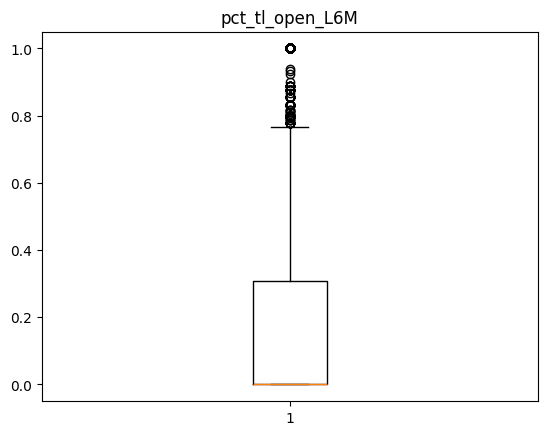

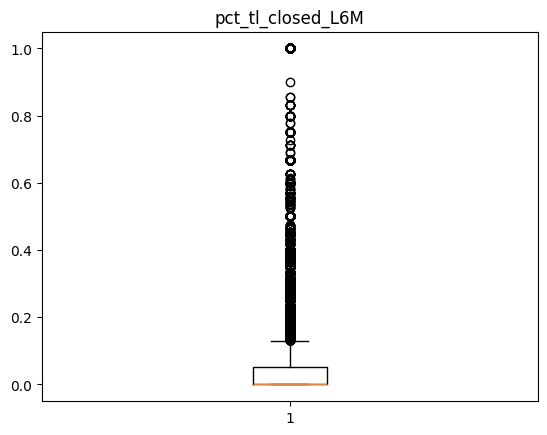

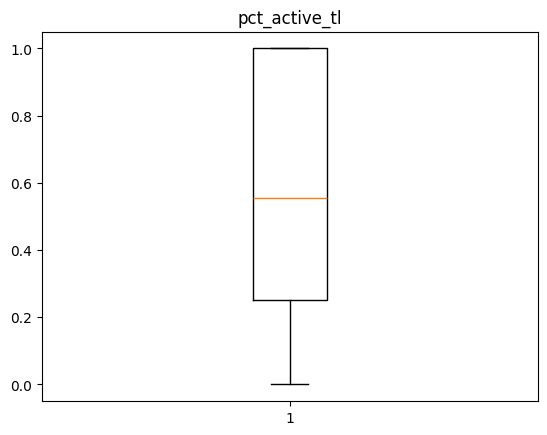

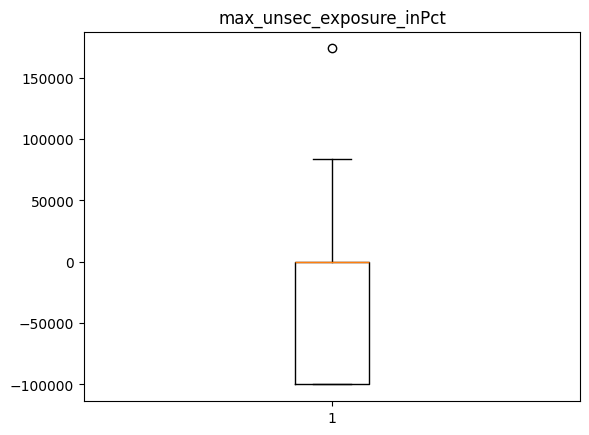

In [12]:
for feature in important_features:
    plt.figure()
    plt.boxplot(
        df_raw[feature]
    )
    plt.title(feature)
    plt.show()

Boxplot Observations

array([[<Axes: xlabel='pct_tl_open_L6M', ylabel='pct_tl_open_L6M'>,
        <Axes: xlabel='pct_tl_closed_L6M', ylabel='pct_tl_open_L6M'>,
        <Axes: xlabel='pct_active_tl', ylabel='pct_tl_open_L6M'>,
        <Axes: xlabel='max_unsec_exposure_inPct', ylabel='pct_tl_open_L6M'>],
       [<Axes: xlabel='pct_tl_open_L6M', ylabel='pct_tl_closed_L6M'>,
        <Axes: xlabel='pct_tl_closed_L6M', ylabel='pct_tl_closed_L6M'>,
        <Axes: xlabel='pct_active_tl', ylabel='pct_tl_closed_L6M'>,
        <Axes: xlabel='max_unsec_exposure_inPct', ylabel='pct_tl_closed_L6M'>],
       [<Axes: xlabel='pct_tl_open_L6M', ylabel='pct_active_tl'>,
        <Axes: xlabel='pct_tl_closed_L6M', ylabel='pct_active_tl'>,
        <Axes: xlabel='pct_active_tl', ylabel='pct_active_tl'>,
        <Axes: xlabel='max_unsec_exposure_inPct', ylabel='pct_active_tl'>],
       [<Axes: xlabel='pct_tl_open_L6M', ylabel='max_unsec_exposure_inPct'>,
        <Axes: xlabel='pct_tl_closed_L6M', ylabel='max_unsec_exposure_inPct'>

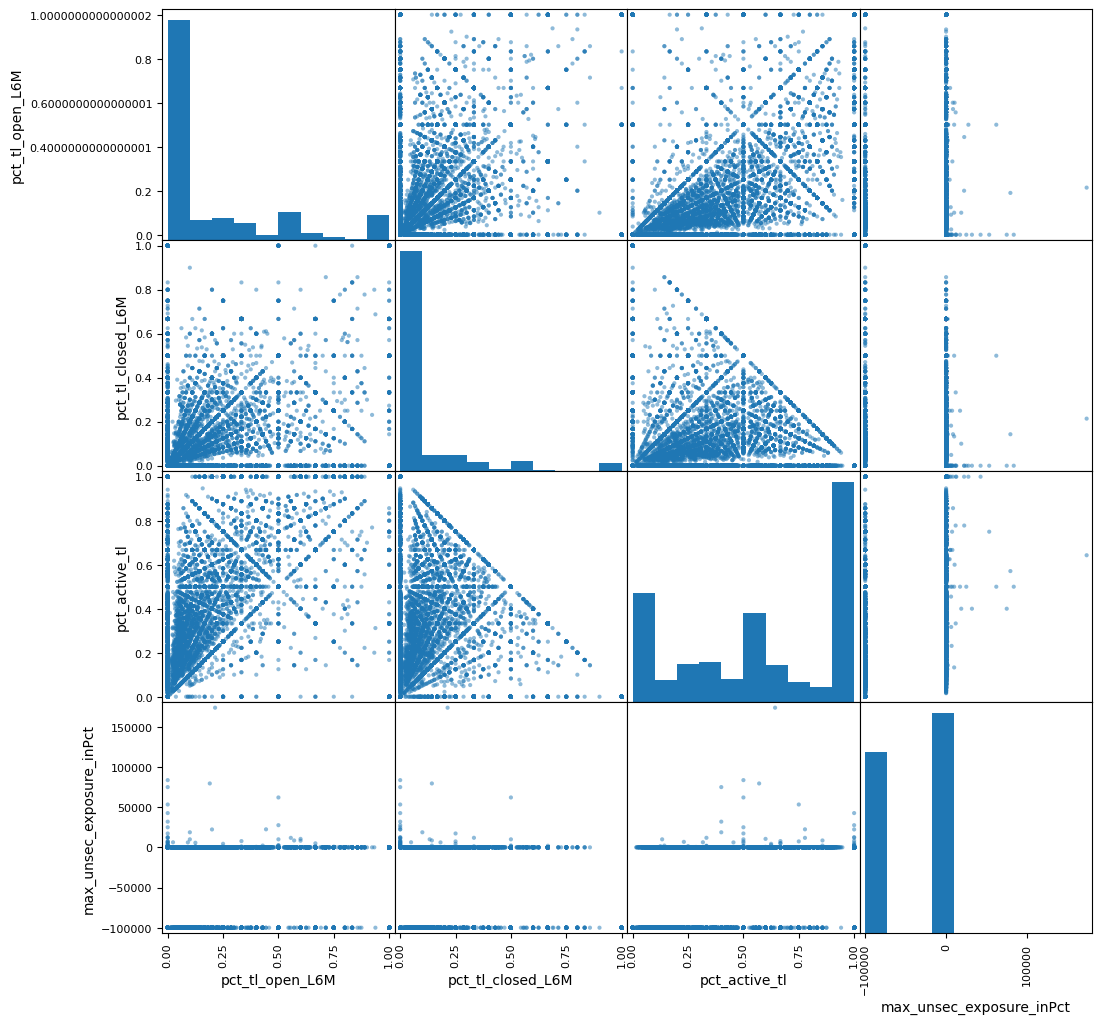

In [ ]:
scatter_matrix(
    df_raw[important_features],
    figsize=(12,12)
)

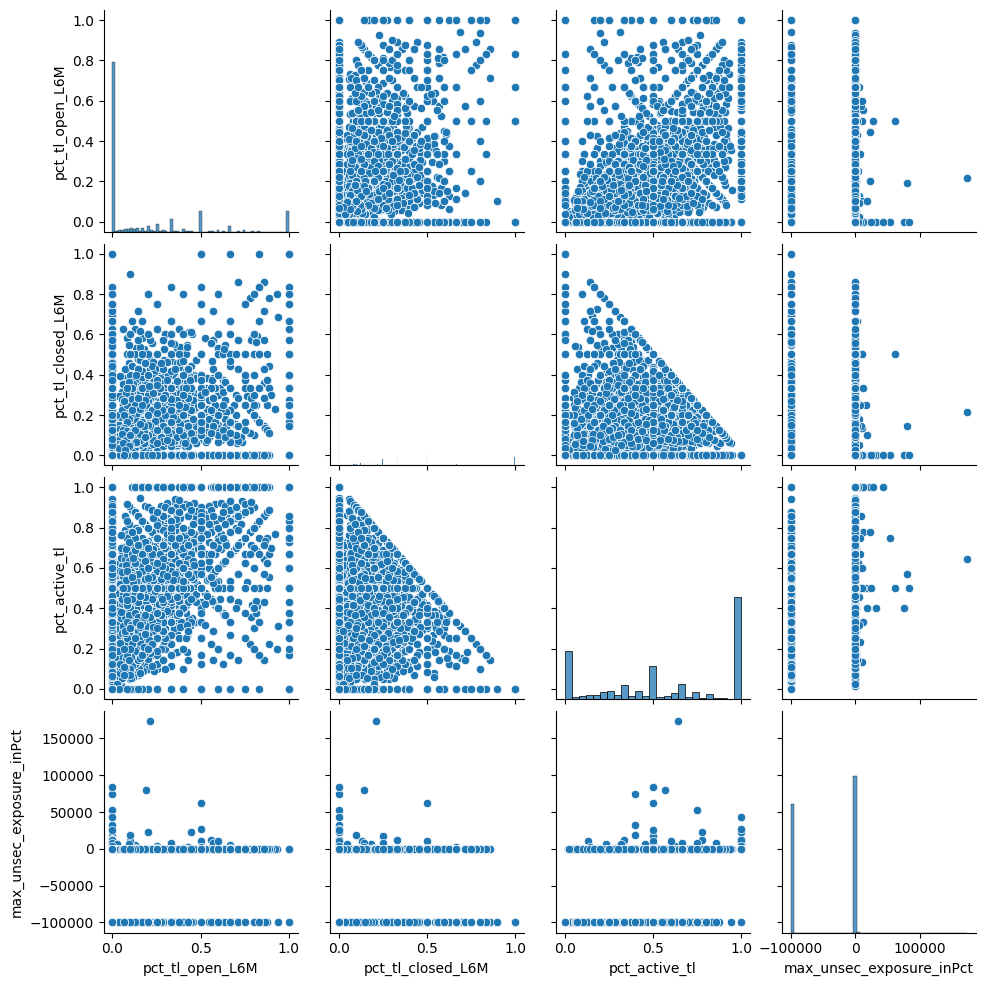

In [ ]:
import seaborn as sns

sns.pairplot(df_raw[important_features])

Explain what these pair plots shows?


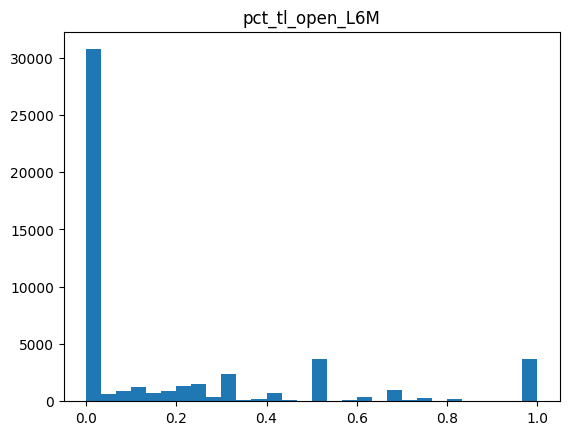

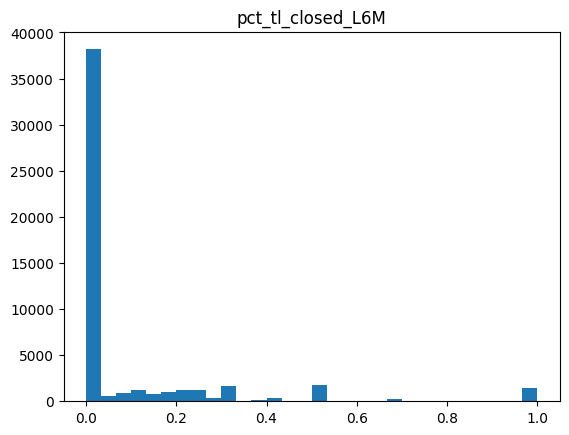

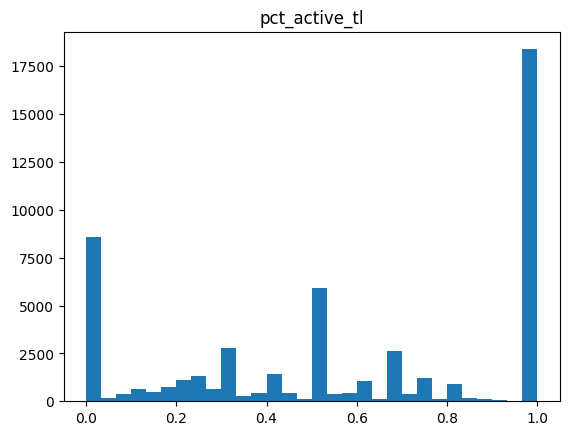

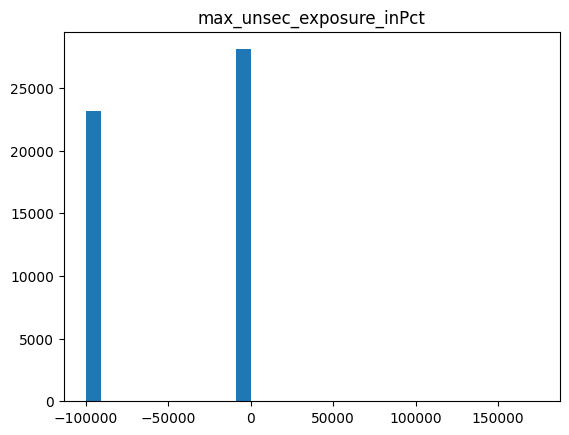

In [13]:
for feature in important_features:
    plt.figure()
    plt.hist(
        df_raw[feature],
        bins=30
    )
    plt.title(feature)
    plt.show()

In [22]:
corr = df_raw.select_dtypes(
    include=np.number
).corr()

In [23]:
corr["Credit_Score"].sort_values(
ascending=False
)

Credit_Score              1.000000
num_std_12mts             0.470303
num_std                   0.464193
num_std_6mts              0.441837
AGE                       0.272582
                            ...   
pct_CC_enq_L6m_of_ever   -0.204150
pct_tl_open_L6M          -0.255157
pct_tl_open_L12M         -0.280756
pct_PL_enq_L6m_of_L12m   -0.378722
pct_PL_enq_L6m_of_ever   -0.387340
Name: Credit_Score, Length: 80, dtype: float64

In [21]:
# df_raw = df_raw.drop(columns=['Unnamed: 0', 'PROSPECTID'])

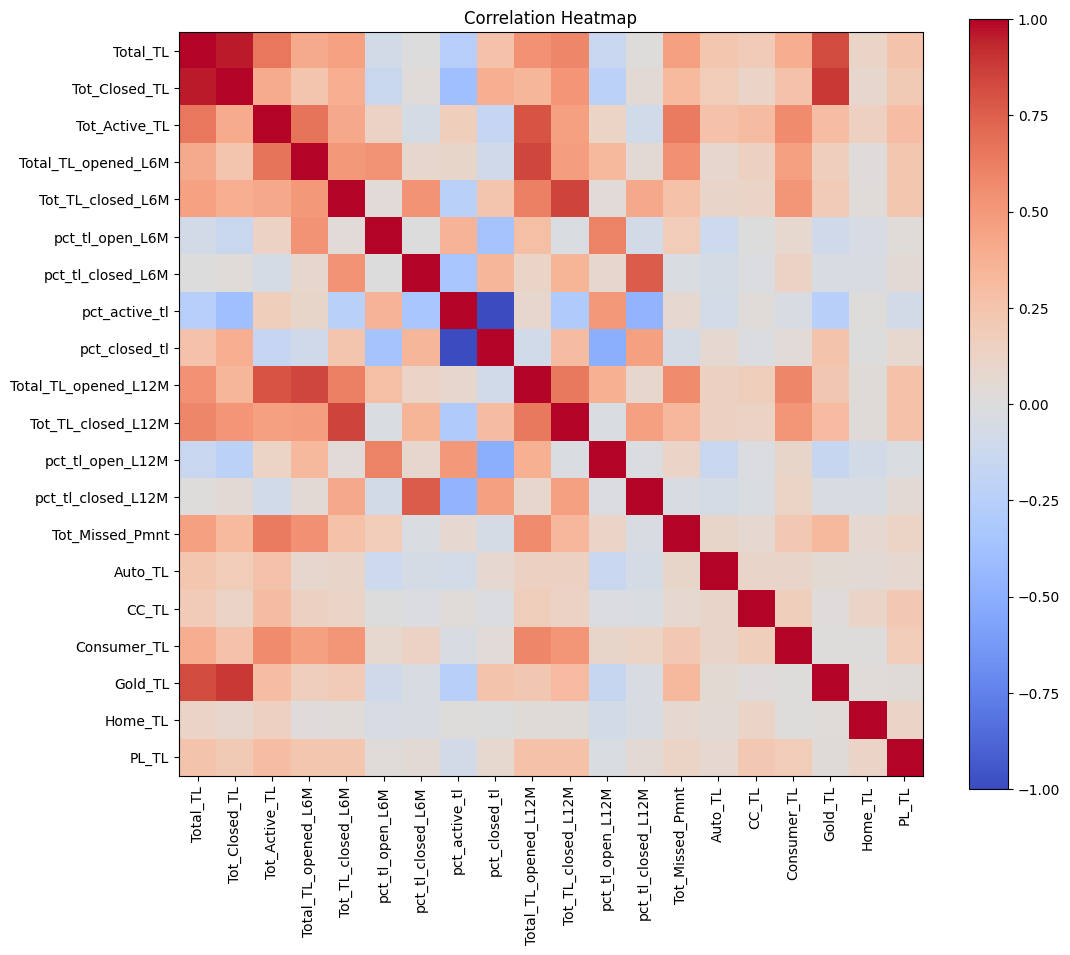

In [24]:
corr_small = corr.iloc[:20,:20]

fig, ax = plt.subplots(figsize=(12,10))

cax = ax.imshow(corr_small, cmap="coolwarm")

plt.xticks(range(len(corr_small.columns)),
           corr_small.columns,
           rotation=90)

plt.yticks(range(len(corr_small.columns)),
           corr_small.columns)

plt.colorbar(cax)

plt.title("Correlation Heatmap")

plt.show()

What correlation plots does?
Give some strong and weak positive correlataion examples from the above heat map
and some strong and weak negative correlation examples

Categorical vs Numerical

In [ ]:
df_raw.groupby(

"Approved_Flag"

).agg({

"Credit_Score":["mean","median"],

"NETMONTHLYINCOME":"mean",

"Total_TL":"mean"

})

Credit_Score        NETMONTHLYINCOME  Total_TL
                      mean median             mean      mean
Approved_Flag                                               
P1              715.952266  712.0     29071.369292  9.923316
P2              682.584614  682.0     25886.794093  4.060530
P3              666.995035  665.0     25938.472088  4.269055
P4              645.629548  650.0     27369.680551  4.977559

In [ ]:
pd.crosstab(
df_raw["Approved_Flag"],
df_raw["GENDER"] #, normalize='index'
)

GENDER,F,M
Approved_Flag,,
P1,609,5194
P2,3951,28248
P3,881,6571
P4,650,5232


Distribution

Normal

Uniform

Right Skewed

Left Skewed

Bimodal

Multimodal

Explain

Why this matters for ML.

### Write Final Observations

This should summarize the EDA, for example:

Is there class imbalance?

Are there highly correlated features?

Which variables contain many outliers?

Which columns have excessive missing values?

Are any feature distributions highly skewed?

Do any values look suspicious or impossible?

Which features appear most related to Credit_Score or Approved_Flag?

### Exercises

Instead of only coding exercises, include interpretation tasks.

Examples:

Which feature is most correlated with Credit_Score?

Which feature has the largest variance?

Which feature has the highest percentage of missing values?

Which variable contains the most outliers?

Is the target class balanced?

Which two features are most strongly correlated?

Which categorical variable has the highest cardinality?

### Write on:
What is univariate analysis?

What is bivariate analysis?

What is multivariate analysis?

What is multicollinearity?

Why do we compute grouped summaries?

Why should EDA be completed before preprocessing?

What is the difference between correlation and causation?

In [ ]:
# transform (log or sqrt), remove, or flag as a binary feature

Notebook	Visualizations
Histograms, KDE, Boxplots, Scatter plots, Pair plots, Heatmaps, Grouped summaries, Class imbalance plots